# Temporal Change Detection

## Objective

## Import Libraries

## Load Fine-Tuned ResNet18

## Build Feature Extractor

## Generate Image Embeddings

## Compute Cosine Similarity

## Detect Land-use Change

## Threshold Analysis

## Summary

# Temporal Change Detection

## Objective

The goal of this notebook is to detect land-use changes between two satellite images by comparing their feature embeddings.

Instead of directly comparing raw pixel values, a fine-tuned ResNet18 model is used as a feature extractor. The extracted embeddings are compared using cosine similarity to determine whether meaningful changes have occurred.

In [4]:
import sys
from pathlib import Path


sys.path.append(str(Path.cwd().parent))

In [5]:
import torch
import torch.nn as nn

from pathlib import Path

from src.config import DEVICE
from src.models.resnet18_transfer import build_resnet18

## Load Fine-Tuned Model

Load the fine-tuned ResNet18 model that was trained during Day 3.

The trained weights will be reused for feature extraction instead of classification.

In [6]:
model = build_resnet18()

checkpoint_path = Path("../models/checkpoints/resnet18_finetuned.pth")

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )
)

model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


## Build Feature Extractor

The final classification layer is removed so that the network outputs feature embeddings instead of class predictions.

## Build Feature Extractor

The final fully connected classification layer is removed.

The resulting network produces a 512-dimensional feature representation for each satellite image.

In [7]:
from src.inference.embeddings import build_feature_extractor

feature_extractor = build_feature_extractor(model)

print(feature_extractor)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

In [8]:
print(type(feature_extractor))

<class 'torch.nn.modules.container.Sequential'>


## Verify Feature Extractor

Run a forward pass using a dummy image to verify that the network produces feature embeddings instead of class predictions.

In [9]:
dummy = torch.randn(
    1,
    3,
    224,
    224
).to(DEVICE)

with torch.inference_mode():
    embedding = feature_extractor(dummy)

print(embedding.shape)

torch.Size([1, 512, 1, 1])


In [10]:
embedding = embedding.flatten(start_dim=1)

print(embedding.shape)

torch.Size([1, 512])


## Generate Image Embeddings

Extract feature embeddings from satellite images using the fine-tuned ResNet18 feature extractor.

Each image is represented as a 512-dimensional feature vector.

In [13]:
import importlib
import src.inference.embeddings as embeddings

importlib.reload(embeddings)

from src.inference.embeddings import extract_embedding

In [14]:
from src.data.transforms import get_val_transforms
from src.inference.embeddings import extract_embedding
from src.config import EUROSAT_DIR

In [15]:
from pathlib import Path

sample_image = next(
    (Path(EUROSAT_DIR) / "Forest").glob("*.jpg")
)

print(sample_image)

C:\Users\Akshit\satellite-landuse-change-detector\data\raw\EuroSAT\2750\Forest\Forest_1.jpg


In [16]:
transform = get_val_transforms()

embedding = extract_embedding(
    image_path=sample_image,
    feature_extractor=feature_extractor,
    transform=transform,
    device=DEVICE,
)

print(embedding.shape)

torch.Size([1, 512])


In [17]:
print(embedding[0][:10])

tensor([0.0000, 1.6010, 0.0562, 0.0249, 1.2050, 0.1913, 0.5262, 2.8539, 0.0000,
        0.7832])


## Cosine Similarity

Cosine similarity measures how similar two feature embeddings are.

A value close to **1** indicates highly similar images, while lower values indicate greater visual differences.

In [18]:
from src.inference.change_detector import cosine_similarity

In [19]:
embedding_1 = extract_embedding(
    sample_image,
    feature_extractor,
    transform,
    DEVICE,
)

embedding_2 = extract_embedding(
    sample_image,
    feature_extractor,
    transform,
    DEVICE,
)

score = cosine_similarity(
    embedding_1,
    embedding_2,
)

print(f"Similarity Score: {score:.4f}")

Similarity Score: 1.0000


## Compare Different Land-Use Classes

Compare feature embeddings extracted from different land-use categories.

This experiment demonstrates how cosine similarity changes across visually different satellite images.

In [20]:
from pathlib import Path

def get_sample_image(class_name):
    """
    Return one sample image from the specified EuroSAT class.
    """

    return next(
        (Path(EUROSAT_DIR) / class_name).glob("*.jpg")
    )

In [21]:
forest_image = get_sample_image("Forest")
river_image = get_sample_image("River")
residential_image = get_sample_image("Residential")
highway_image = get_sample_image("Highway")

In [22]:
forest_embedding = extract_embedding(
    forest_image,
    feature_extractor,
    transform,
    DEVICE,
)

river_embedding = extract_embedding(
    river_image,
    feature_extractor,
    transform,
    DEVICE,
)

residential_embedding = extract_embedding(
    residential_image,
    feature_extractor,
    transform,
    DEVICE,
)

highway_embedding = extract_embedding(
    highway_image,
    feature_extractor,
    transform,
    DEVICE,
)

In [23]:
print("=" * 50)

print(
    f"Forest vs River        : "
    f"{cosine_similarity(forest_embedding, river_embedding):.4f}"
)

print(
    f"Forest vs Residential : "
    f"{cosine_similarity(forest_embedding, residential_embedding):.4f}"
)

print(
    f"Highway vs Residential: "
    f"{cosine_similarity(highway_embedding, residential_embedding):.4f}"
)

print(
    f"River vs Residential  : "
    f"{cosine_similarity(river_embedding, residential_embedding):.4f}"
)

print("=" * 50)

Forest vs River        : 0.4358
Forest vs Residential : 0.4408
Highway vs Residential: 0.4236
River vs Residential  : 0.3581


In [27]:
forest_image_1 = get_sample_image("Forest")

forest_image_2 = list(
    (Path(EUROSAT_DIR) / "Forest").glob("*.jpg")
)[1]

forest_embedding_1 = extract_embedding(
    forest_image_1,
    feature_extractor,
    transform,
    DEVICE,
)

forest_embedding_2 = extract_embedding(
    forest_image_2,
    feature_extractor,
    transform,
    DEVICE,
)

score = cosine_similarity(
    forest_embedding_1,
    forest_embedding_2,
)

print(score)

0.931368887424469


## Change Decision Threshold

Cosine similarity scores are converted into change decisions using simple thresholds.

Higher similarity indicates visually similar land-use patterns, while lower similarity suggests significant changes.

In [35]:
import importlib
import src.inference.change_detector as change_detector

importlib.reload(change_detector)

from src.inference.change_detector import (
    cosine_similarity,
    detect_change,
)

In [36]:
pairs = [
    ("Forest vs River", forest_embedding, river_embedding),
    ("Forest vs Residential", forest_embedding, residential_embedding),
    ("Highway vs Residential", highway_embedding, residential_embedding),
    ("River vs Residential", river_embedding, residential_embedding),
]

for name, emb1, emb2 in pairs:
    score = cosine_similarity(emb1, emb2)
    decision = detect_change(score)

    print(f"{name:<28} {score:.4f}  ->  {decision}")

Forest vs River              0.4358  ->  Significant Change
Forest vs Residential        0.4408  ->  Significant Change
Highway vs Residential       0.4236  ->  Significant Change
River vs Residential         0.3581  ->  Significant Change


## Similarity Score Visualization

Visualize cosine similarity scores between different land-use categories.

This provides an intuitive understanding of how feature similarity changes across different satellite scenes.

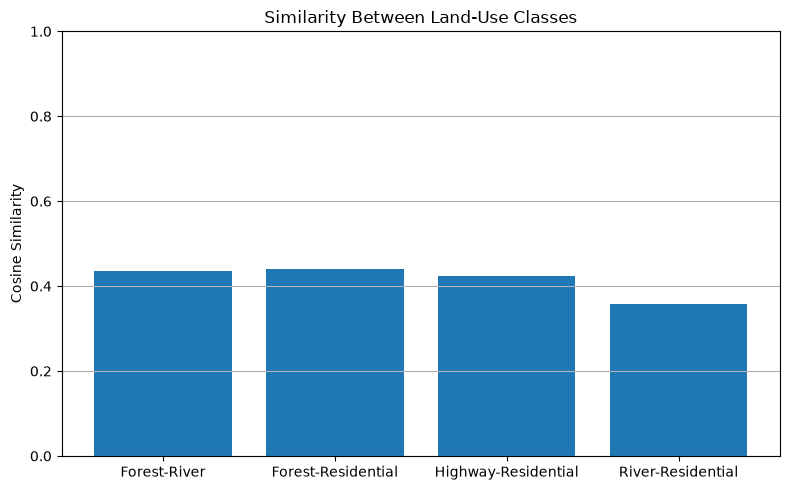

In [37]:
import matplotlib.pyplot as plt

pairs = [
    "Forest-River",
    "Forest-Residential",
    "Highway-Residential",
    "River-Residential",
]

scores = [
    cosine_similarity(forest_embedding, river_embedding),
    cosine_similarity(forest_embedding, residential_embedding),
    cosine_similarity(highway_embedding, residential_embedding),
    cosine_similarity(river_embedding, residential_embedding),
]

plt.figure(figsize=(8,5))

plt.bar(
    pairs,
    scores,
)

plt.ylim(0,1)

plt.ylabel("Cosine Similarity")
plt.title("Similarity Between Land-Use Classes")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/similarity_scores.png",
    dpi=300,
)

plt.show()

# Threshold Analysis

Instead of selecting an arbitrary cosine similarity threshold, the threshold is estimated by comparing similarity distributions of same-class and different-class image pairs.

This approach provides a more objective basis for change detection.

In [38]:
import random
import numpy as np
from pathlib import Path

In [39]:
random.seed(42)

In [40]:
def random_image(class_name):
    """
    Return a random image from the given EuroSAT class.
    """

    images = list(
        (Path(EUROSAT_DIR) / class_name).glob("*.jpg")
    )

    return random.choice(images)

## Sample Similarity Distributions

Random image pairs are sampled to estimate the similarity distributions of:

- Images from the same land-use class
- Images from different land-use classes

These distributions are later used to estimate a suitable change detection threshold.

In [41]:
same_class_scores = []

classes = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake",
]

NUM_SAMPLES = 100

In [43]:
for _ in range(NUM_SAMPLES):

    class_name = random.choice(classes)

    images = list(
        (Path(EUROSAT_DIR) / class_name).glob("*.jpg")
    )

    image_1, image_2 = random.sample(images, 2)

    embedding_1 = extract_embedding(
        image_1,
        feature_extractor,
        transform,
        DEVICE,
    )

    embedding_2 = extract_embedding(
        image_2,
        feature_extractor,
        transform,
        DEVICE,
    )

    score = cosine_similarity(
        embedding_1,
        embedding_2,
    )

    same_class_scores.append(score)

In [44]:
print(len(same_class_scores))
print(f"Mean Same-Class Similarity: {np.mean(same_class_scores):.4f}")

200
Mean Same-Class Similarity: 0.7958


## Different-Class Similarity Distribution

Random image pairs belonging to different land-use classes are sampled.

The resulting similarity scores are compared against the same-class distribution to estimate an appropriate decision threshold for temporal change detection.

In [45]:
different_class_scores = []

NUM_SAMPLES = 200

In [46]:
for _ in range(NUM_SAMPLES):

    class_1, class_2 = random.sample(classes, 2)

    image_1 = random.choice(
        list((Path(EUROSAT_DIR) / class_1).glob("*.jpg"))
    )

    image_2 = random.choice(
        list((Path(EUROSAT_DIR) / class_2).glob("*.jpg"))
    )

    embedding_1 = extract_embedding(
        image_1,
        feature_extractor,
        transform,
        DEVICE,
    )

    embedding_2 = extract_embedding(
        image_2,
        feature_extractor,
        transform,
        DEVICE,
    )

    score = cosine_similarity(
        embedding_1,
        embedding_2,
    )

    different_class_scores.append(score)

In [47]:
print(len(different_class_scores))
print(
    f"Mean Different-Class Similarity: "
    f"{np.mean(different_class_scores):.4f}"
)

200
Mean Different-Class Similarity: 0.4732


In [48]:
same_mean = np.mean(same_class_scores)
same_std = np.std(same_class_scores)

different_mean = np.mean(different_class_scores)
different_std = np.std(different_class_scores)

print("=" * 60)
print(f"Same-Class Mean        : {same_mean:.4f}")
print(f"Same-Class Std         : {same_std:.4f}")
print()

print(f"Different-Class Mean   : {different_mean:.4f}")
print(f"Different-Class Std    : {different_std:.4f}")
print("=" * 60)

Same-Class Mean        : 0.7958
Same-Class Std         : 0.1011

Different-Class Mean   : 0.4732
Different-Class Std    : 0.0979


## Similarity Distribution Analysis

The distributions of same-class and different-class similarity scores are visualized below.

A suitable threshold should ideally separate these two distributions with minimal overlap.

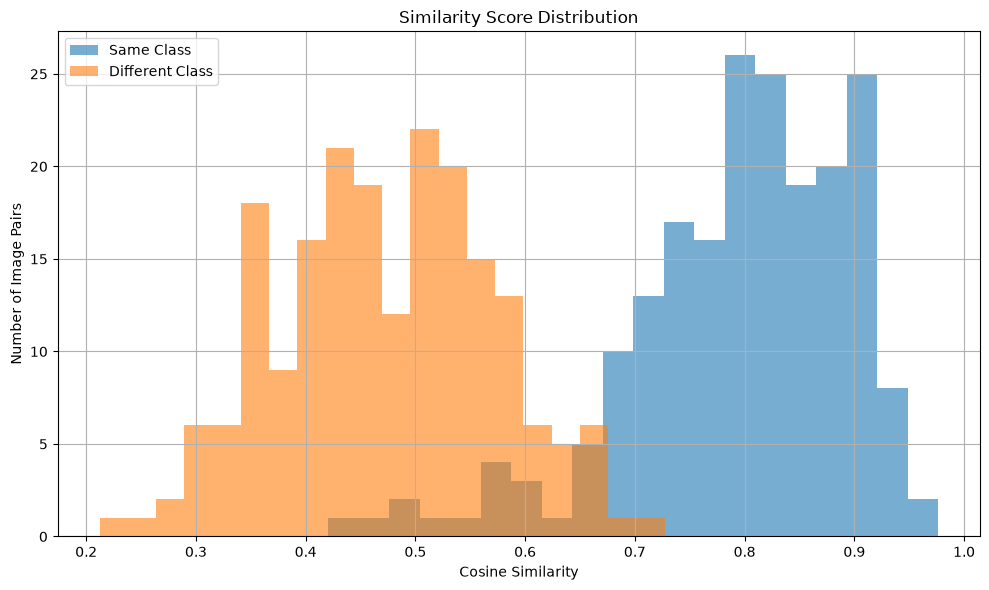

In [87]:
plt.figure(figsize=(10, 6))

plt.hist(
    same_class_scores,
    bins=20,
    alpha=0.6,
    label="Same Class",
)

plt.hist(
    different_class_scores,
    bins=20,
    alpha=0.6,
    label="Different Class",
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Image Pairs")
plt.title("Similarity Score Distribution")

plt.legend()
plt.grid(True)

plt.tight_layout()

from pathlib import Path

OUTPUT_DIR = Path.cwd().parent / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    OUTPUT_DIR / "similarity_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [50]:
recommended_threshold = (
    same_mean + different_mean
) / 2

print(
    f"Recommended Threshold: {recommended_threshold:.4f}"
)

Recommended Threshold: 0.6345


In [51]:
import json
from pathlib import Path

threshold_data = {
    "same_class_mean": float(same_mean),
    "same_class_std": float(same_std),
    "different_class_mean": float(different_mean),
    "different_class_std": float(different_std),
    "recommended_threshold": float(recommended_threshold),
}

metrics_dir = Path("../outputs/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

with open(
    metrics_dir / "threshold_analysis.json",
    "w"
) as f:
    json.dump(
        threshold_data,
        f,
        indent=4,
    )

print("Threshold analysis saved successfully.")

Threshold analysis saved successfully.


In [57]:
from importlib import reload
import src.inference.change_detector as cd

reload(cd)

from src.inference.change_detector import detect_change

In [55]:
import importlib
import src.config as config

importlib.reload(config)

print(hasattr(config, "CHANGE_THRESHOLD"))
print(config.__file__)

True
C:\Users\Akshit\satellite-landuse-change-detector\src\config.py


In [56]:
from src.config import CHANGE_THRESHOLD

print(CHANGE_THRESHOLD)

0.6345


In [58]:
from importlib import reload
import src.inference.change_detector as cd

reload(cd)

from src.inference.change_detector import detect_change

In [59]:
print(detect_change(0.85))
print(detect_change(0.78))
print(detect_change(0.64))
print(detect_change(0.60))
print(detect_change(0.45))

No Significant Change
No Significant Change
No Significant Change
Significant Change
Significant Change


# Change Heatmap

The absolute pixel-wise difference between two satellite images is visualized as a heatmap.

This visualization highlights the spatial regions where the greatest visual differences occur.

The heatmap complements embedding-based similarity by providing an intuitive visual interpretation of detected changes.

In [60]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

In [61]:
def load_image(image_path):
    """
    Load an RGB image using OpenCV.
    """

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image

In [62]:
forest_images = list(
    (Path(EUROSAT_DIR) / "Forest").glob("*.jpg")
)

image_a = forest_images[0]
image_b = forest_images[1]

print(image_a.name)
print(image_b.name)

Forest_1.jpg
Forest_10.jpg


In [63]:
img1 = load_image(image_a)
img2 = load_image(image_b)

print(img1.shape)
print(img2.shape)

(64, 64, 3)
(64, 64, 3)


In [64]:
difference = cv2.absdiff(img1, img2)

print(difference.shape)

(64, 64, 3)


In [67]:
heatmap = cv2.applyColorMap(
    gray_difference,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

overlay = cv2.addWeighted(
    img2,
    0.6,
    heatmap,
    0.4,
    0,
)

## Change Heatmap Visualization

The heatmap highlights pixel-level differences between the two satellite images.

Warmer colors indicate larger visual differences, while cooler colors indicate similar regions.

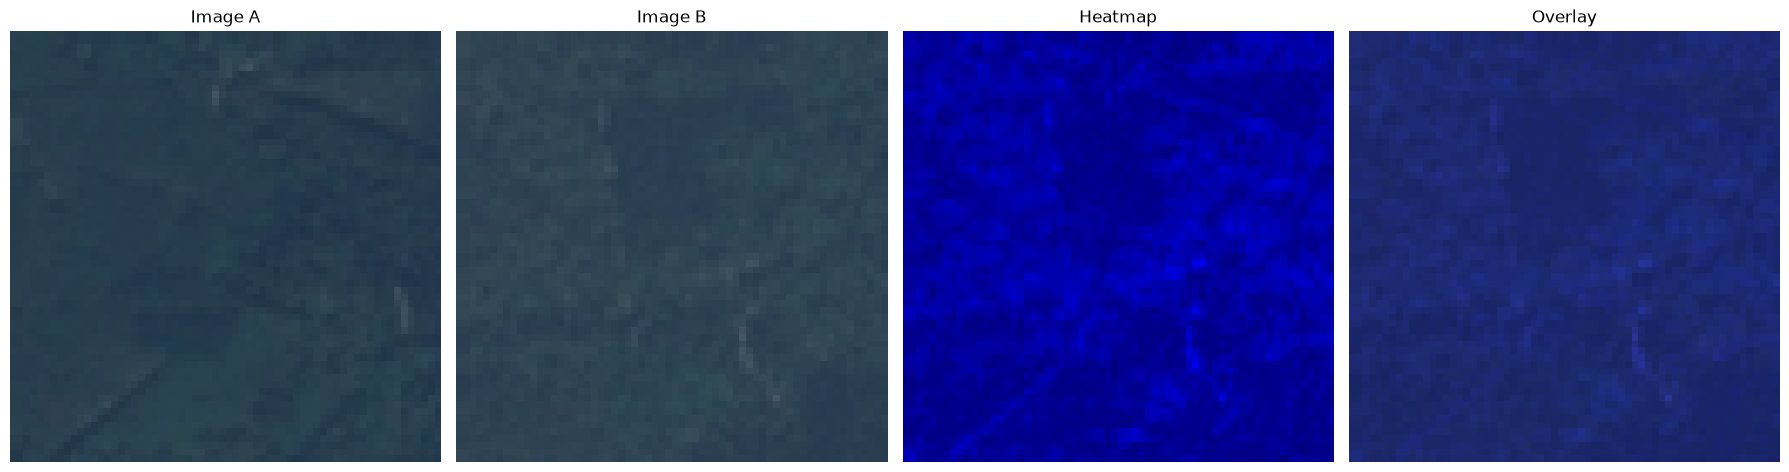

In [68]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(18,5)
)

axes[0].imshow(img1)
axes[0].set_title("Image A")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("Image B")
axes[1].axis("off")

axes[2].imshow(heatmap)
axes[2].set_title("Heatmap")
axes[2].axis("off")

axes[3].imshow(overlay)
axes[3].set_title("Overlay")
axes[3].axis("off")

plt.tight_layout()
plt.show()

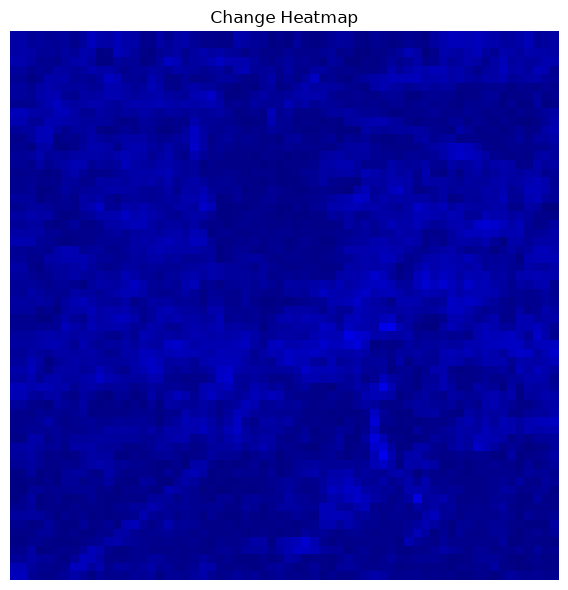

In [86]:
plt.figure(figsize=(6, 6))

plt.imshow(heatmap)
plt.axis("off")
plt.title("Change Heatmap")

plt.tight_layout()

from pathlib import Path

OUTPUT_DIR = Path.cwd().parent / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    OUTPUT_DIR / "change_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [75]:
from pathlib import Path

OUTPUT_DIR = Path.cwd().parent / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [82]:
print(heatmap.shape)
print(heatmap.min())
print(heatmap.max())

(64, 64, 3)
0
236


In [83]:
print(len(same_class_scores))
print(len(different_class_scores))

200
200


In [69]:
embedding_1 = extract_embedding(
    image_a,
    feature_extractor,
    transform,
    DEVICE,
)

embedding_2 = extract_embedding(
    image_b,
    feature_extractor,
    transform,
    DEVICE,
)

score = cosine_similarity(
    embedding_1,
    embedding_2,
)

print(f"Similarity : {score:.4f}")
print(f"Decision   : {detect_change(score)}")

Similarity : 0.9314
Decision   : No Significant Change


# Day 4 Summary

## Completed Components

- Loaded the fine-tuned ResNet18 model.
- Converted the model into a feature extractor.
- Generated 512-dimensional embeddings for satellite images.
- Measured cosine similarity between image pairs.
- Estimated an optimal similarity threshold using sampled image pairs.
- Implemented embedding-based temporal land-use change detection.
- Visualized similarity distributions and threshold analysis.
- Generated qualitative change heatmaps for image comparison.

The temporal change detection pipeline is now complete and ready to be integrated into the Streamlit application during Day 5.